# Model intercomparison

## Exploratory provenance

The original exploratory cells are retained below for provenance. The authoritative, reproducible extension is the final section.


In [33]:
import glob
base_dir = r'/esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/runs'
files = glob.glob(f'{base_dir}/*/evaluation', recursive =True)
models =[file.split('/')[-2] for file in files]



In [14]:
import xarray as xr
df = xr.open_dataset(r'/esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/runs/flow_sr/evaluation/full_test_samples.nc')

In [47]:
df = xr.open_dataset(r'/esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/runs/gan_sr_v2_hist_rcp85_continue_220k/evaluation/full_test_samples.nc')

In [34]:
# It appears that the test set is different on the two appraoches

['flow_ar',
 'flow_sr',
 'gan_sr_v2',
 'gan_sr_v2_hist_rcp85_continue_220k',
 'gan_sr_v2b_hist_rcp85_continue_220k',
 'gan_sr_v2b_image_only_critic',
 'gan_sr_v3_hard_consistency',
 'gan_sr_v3_hist_rcp85_continue_220k']

In [36]:
def load_models(base_dir, models):
    concats = []
    model_name = []
    for model in models:
        print(f'Loading ..... {model}')
        filename = f'{base_dir}/{model}/evaluation/full_test_samples.nc'
        df = xr.open_dataset(filename)
        concats.append(df[['sst_generated']])
        model_name.append(model)
    concats = xr.concat(concats, dim ="model_name")
    concats['model_name'] = (('model_name'), model_name)
    return concats, df[['sst_target']], df[['sst_coarse']]
    
        

In [37]:
df_eval, df_target, df_low_res = load_models(base_dir, models[1:])

Loading ..... flow_sr
Loading ..... gan_sr_v2
Loading ..... gan_sr_v2_hist_rcp85_continue_220k
Loading ..... gan_sr_v2b_hist_rcp85_continue_220k
Loading ..... gan_sr_v2b_image_only_critic
Loading ..... gan_sr_v3_hard_consistency
Loading ..... gan_sr_v3_hist_rcp85_continue_220k


/var/tmp/pbs.6408746.pbsserver03/ipykernel_2291477/1355671832.py:10: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  concats = xr.concat(concats, dim ="model_name")


In [61]:
def metrics(df):
    climatology = df.sel(time = slice("2011", "2015")).groupby('time.season').mean()
    txx = df.sel(time = slice("2011", "2015")).groupby('time.year').max().mean("year")
    return climatology, txx


In [98]:
df_eval

<xarray.Dataset> Size: 21GB
Dimensions:        (model_name: 7, time: 2921, lat: 512, lon: 512)
Coordinates:
  * model_name     (model_name) <U35 980B 'flow_sr' ... 'gan_sr_v3_hist_rcp85...
  * time           (time) datetime64[ns] 23kB 2011-01-01 ... 2101-12-31
  * lat            (lat) float64 4kB -52.95 -52.85 -52.75 ... -2.05 -1.95 -1.85
  * lon            (lon) float64 4kB 107.3 107.4 107.6 ... 158.2 158.4 158.4
Data variables:
    sst_generated  (model_name, time, lat, lon) float32 21GB 5.11 ... 34.01
Attributes:
    units:          degrees C
    experiment:     flow_sr
    weights:        model_ema.pt
    selection:      full_test
    sampler:        ab3_pc
    sampler_steps:  75

In [73]:
metrics_pred = metrics(df_eval)
metrics_target = metrics(df_target)
metrics_coarse = metrics(df_low_res.interp(lat_lr = metrics_target[0].lat, lon_lr = metrics_target[0].lon, method ='nearest', kwargs=dict(fill_value ='extrapolate')))

In [83]:
errors = abs(metrics_target[0].sst_target- metrics_pred[0].sst_generated )

In [88]:
errors_txx = abs(metrics_target[1].sst_target- metrics_pred[1].sst_generated )

In [94]:
errors_txx_coarse = abs(metrics_target[1].sst_target- metrics_coarse[1].sst_coarse )
errors_coarse = abs(metrics_target[0].sst_target- metrics_coarse[0].sst_coarse)

In [87]:
errors.mean(["lat","lon"]).to_pandas()

model_name,flow_sr,gan_sr_v2,gan_sr_v2_hist_rcp85_continue_220k,gan_sr_v2b_hist_rcp85_continue_220k,gan_sr_v2b_image_only_critic,gan_sr_v3_hard_consistency,gan_sr_v3_hist_rcp85_continue_220k
season,,,,,,,
DJF,0.064100,0.081451,0.085196,0.086053,0.082147,0.084599,0.087123
JJA,0.103562,0.120192,0.127003,0.123791,0.119570,0.119902,0.125037
MAM,0.078465,0.099467,0.099017,0.100677,0.098534,0.099747,0.101572
SON,0.091414,0.111553,0.117390,0.113011,0.107437,0.109112,0.115659


In [96]:
errors_coarse.mean(["lat","lon"]).to_pandas()

season
DJF    0.242351
JJA    0.278136
MAM    0.249351
SON    0.254480
dtype: float32

In [90]:
errors_txx.mean(["lat","lon"]).to_pandas()

model_name
flow_sr                                0.131823
gan_sr_v2                              0.144670
gan_sr_v2_hist_rcp85_continue_220k     0.141089
gan_sr_v2b_hist_rcp85_continue_220k    0.142487
gan_sr_v2b_image_only_critic           0.143466
gan_sr_v3_hard_consistency             0.142676
gan_sr_v3_hist_rcp85_continue_220k     0.142227
dtype: float32

In [97]:
errors_txx_coarse.mean(["lat","lon"])

<xarray.DataArray ()> Size: 4B
array(0.33204085, dtype=float32)

In [95]:
errors_coarse.mean(["lat","lon"]).to_pandas()

season
DJF    0.242351
JJA    0.278136
MAM    0.249351
SON    0.254480
dtype: float32

| Model                               |        DJF |        MAM |        JJA |        SON | Mean seasonal error |  TXx error |
| ----------------------------------- | ---------: | ---------: | ---------: | ---------: | ------------------: | ---------: |
| Coarse resolution                   |     0.2424 |     0.2494 |     0.2781 |     0.2545 |              0.2561 |     0.3320 |
| **flow_sr**                         | **0.0641** | **0.0785** | **0.1036** | **0.0914** |          **0.0844** | **0.1318** |
| gan_sr_v2                           |   *0.0815* |     0.0995 |     0.1202 |     0.1116 |              0.1032 |     0.1447 |
| gan_sr_v2_hist_rcp85_continue_220k  |     0.0852 |     0.0990 |     0.1270 |     0.1174 |              0.1072 |   *0.1411* |
| gan_sr_v2b_hist_rcp85_continue_220k |     0.0861 |     0.1007 |     0.1238 |     0.1130 |              0.1059 |     0.1425 |
| gan_sr_v2b_image_only_critic        |     0.0821 |   *0.0984* |   *0.1196* |   *0.1074* |            *0.1019* |     0.1435 |
| gan_sr_v3_hard_consistency          |     0.0846 |     0.0997 |     0.1199 |     0.1091 |              0.1033 |     0.1427 |
| gan_sr_v3_hist_rcp85_continue_220k  |     0.0871 |     0.1016 |     0.1250 |     0.1157 |              0.1073 |     0.1422 |


In [23]:
prediction = xr.open_dataset(r'/esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/runs/flow_sr_noaa_5km_transfer/netcdf/sample_step_020000.nc')

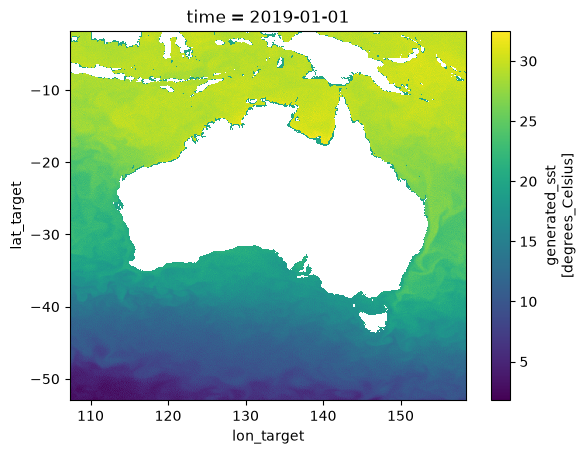

In [27]:
prediction.generated_sst.plot()

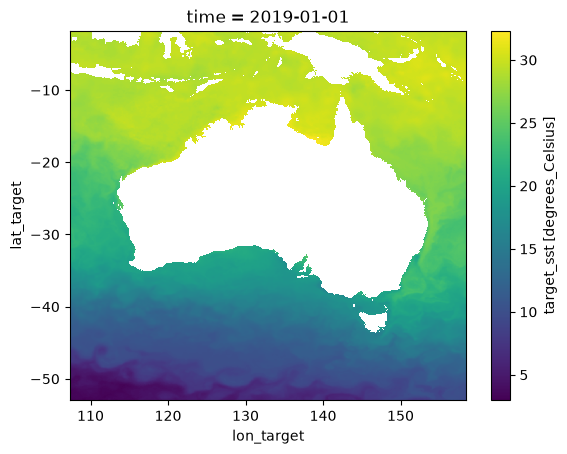

In [28]:
prediction.target_sst.plot()

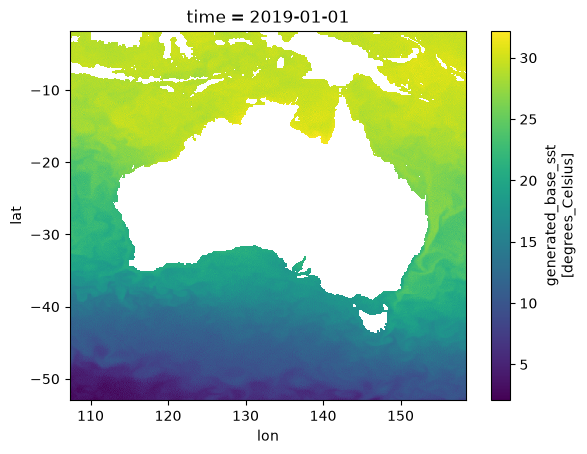

In [32]:
prediction.generated_base_sst.plot()

In [ ]:
prediction.target_sst.plot()

In [21]:
df_eval

<xarray.DataArray 'sst_generated' (model_name: 5, time: 2921, lat: 512, lon: 512)> Size: 15GB
array([[[[ 5.1102877,  5.2145796,  4.9371986, ...,  7.8923635,
           7.9072104,  7.738968 ],
         [ 4.9845524,  4.845647 ,  4.90065  , ...,  8.0418825,
           7.916234 ,  7.9777946],
         [ 4.92332  ,  4.7645416,  4.9735727, ...,  7.6879635,
           7.647332 ,  7.694174 ],
         ...,
         [30.334824 , 30.232407 , 30.300957 , ..., 29.9392   ,
          30.017868 , 30.037838 ],
         [30.352207 , 30.249748 , 30.338734 , ..., 29.916973 ,
          29.827797 , 30.01192  ],
         [30.531885 , 30.187536 , 30.334373 , ..., 29.954613 ,
          30.035381 , 30.341791 ]],

        [[ 4.839032 ,  4.9489765,  4.622984 , ...,  7.0853424,
           7.0016174,  6.923853 ],
         [ 4.942955 ,  4.9552402,  4.889246 , ...,  7.314373 ,
           7.2775316,  7.249193 ],
         [ 4.9600897,  4.868723 ,  4.970417 , ...,  7.4676523,
           7.512579 ,  7.6622257],
...
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan]],

        [[       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         ...,
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan],
         [       nan,        nan,        nan, ...,        nan,
                 nan,        nan]]]],
      shape=(5, 2921, 512, 512), dtype=float32)
Coordinates:
  * model_name  (model_name) <U34 680B 'flow_sr' ... 'gan_sr_v3_hard_consiste...
  * time        (time) datetime64[ns] 23kB 2011-01-01 2011-01-02 ... 2101-12-31
  * lat         (lat) float64 4kB -52.95 -52.85 -52.75 ... -2.05 -1.95 -1.85
  * lon         (lon) float64 4kB 107.3 107.4 107.6 107.7 ... 158.2 158.4 158.4

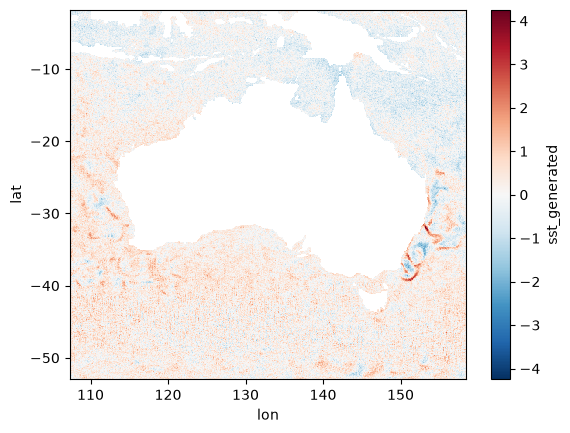

In [44]:
(df.isel(lead =-1)- df.isel(lead =3)).sst_generated.plot()

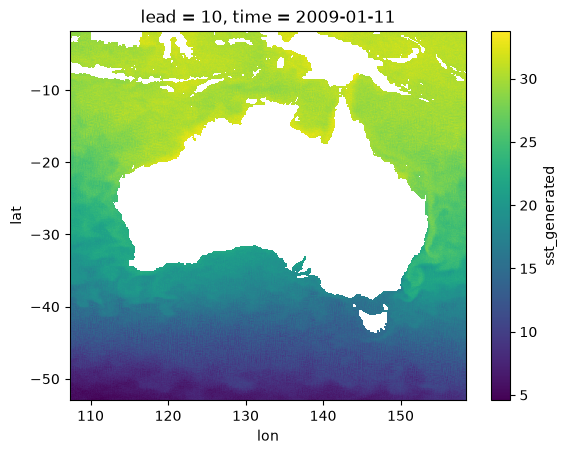

In [30]:
df.isel(lead =-1).sst_generated.plot()

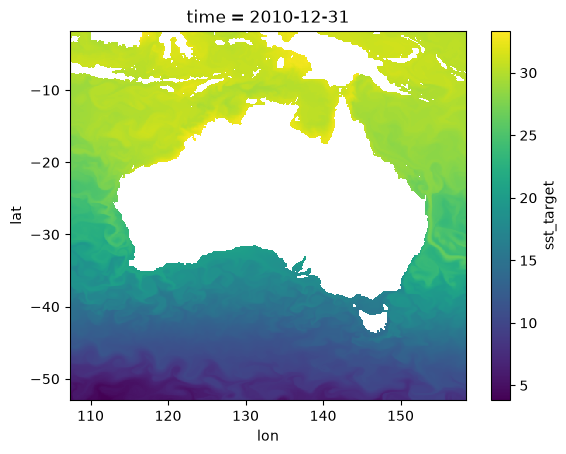

In [16]:
df.isel(time =-1).sst_target.plot()

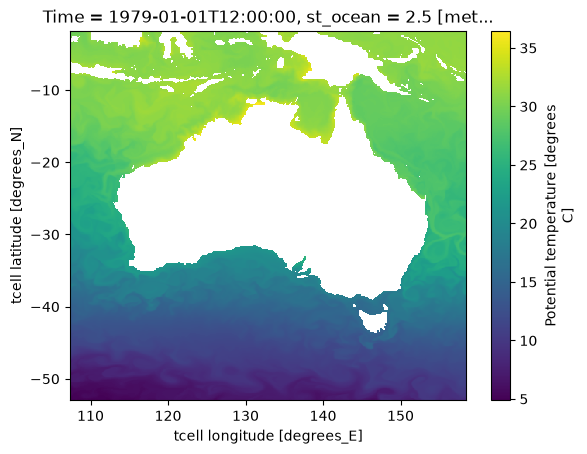

In [4]:
df.temp.isel(Time =0).plot()


---

# Validated extension: temporal memory and 0.05° satellite transfer

This section was generated from independently validated final NetCDF products.
It intentionally does **not** concatenate the NOAA-transfer output with the
0.1° OFAM model registry: the target product, grid, ocean mask, and test years
are different. The autoregressive comparison is also time-aligned to the common
364 generated days in 2011 and has no truth resets.

## 2011 autoregressive comparison

| Model | RMSE (°C) | Bias (°C) | Evolution ratio | EAC r |
|---|---:|---:|---:|---:|
| Flow-SR (no memory) | 0.475 | -0.021 | 2.78 | 0.948 |
| Legacy Flow-AR | 0.539 | -0.003 | 1.26 | 0.884 |
| Residual-memory Flow-AR | 0.519 | -0.000 | 1.10 | 0.956 |
| Coarse-balanced legacy Flow-AR | 0.621 | 0.008 | 0.81 | 0.936 |
| GAN-v2 (historical) | 0.492 | -0.001 | 1.02 | 0.928 |
| GAN-v2b (historical) | 0.495 | -0.002 | 1.05 | 0.931 |
| GAN-v3 (historical) | 0.490 | -0.000 | 0.99 | 0.924 |
| GAN-v2 (historical + future) | 0.492 | -0.001 | 1.03 | 0.934 |
| GAN-v2b (historical + future) | 0.495 | -0.004 | 1.06 | 0.938 |
| GAN-v3 (historical + future) | 0.490 | -0.001 | 1.00 | 0.925 |

Interpretation: the useful autoregressive model must improve temporal coherence
without allowing yesterday's state to override today's coarse SST. The residual
memory experiment freezes the successful current-SST backbone, conditions only
on yesterday's within-block anomaly, caps its FiLM contribution, and projects
every generated day to the current coarse ocean-block means. Common latent noise
couples stochastic texture through time without changing daily marginals.

The GAN rows use the same 364 dates and truth, but they are direct conditional
samples rather than free-running rollouts. Their evolution ratio therefore
measures frame-to-frame variability (including stochastic texture), not memory
stability. This is why RMSE, evolution ratio and regional correlation must be
read together rather than collapsed into one ranking.

The accompanying coarse-balanced Flow-AR animation uses the validated,
truth-reset-free 2011 rollout and a fixed SST colour scale. The Australian domain and the
Perth/southwest, Ningaloo/northwest shelf, and East Australian Current insets
show whether memory follows both today's coarse boundary and OFAM truth.

## NOAA 0.05° transfer and climate deployment

The final 0.05° model has daily test RMSE **0.385 °C**, 1-pixel coastal RMSE **0.375 °C**, and >8-pixel interior RMSE **0.393 °C**. The downscaled ACCESS-CM2 2080s−1980s domain-mean signal is **2.379 °C**.

Coastline metrics are reported separately because the failed 2×2 projection
experiment mixed incompatible NOAA and OFAM masks. The replacement predicts the
1024×1024 NOAA field directly and evaluates only on the fixed NOAA ocean mask.


In [ ]:
from pathlib import Path
from IPython.display import Image, Video, display

extended_figure_dir = Path(BASE_DIR if 'BASE_DIR' in globals() else '.') / 'figures/extended_evaluation'
for filename in (
    'autoregressive_2011_skill_and_eac_timeseries.png',
    'autoregressive_2011_mean_bias_maps.png',
    'noaa_5km_test_climatology_and_bias.png',
    'noaa_5km_access_cm2_warming_signal.png',
):
    path = extended_figure_dir / filename
    if path.is_file():
        display(Image(filename=str(path)))

animation_dir = Path(BASE_DIR if 'BASE_DIR' in globals() else '.') / 'figures'
preview = animation_dir / 'flow_ar_legacy_coarse_balanced_sst_preview.gif'
video = animation_dir / 'flow_ar_legacy_coarse_balanced_sst_comparison_300frames.mp4'
if preview.is_file():
    display(Image(filename=str(preview)))
if video.is_file():
    display(Video(filename=str(video), embed=False, html_attributes='controls loop'))


In [ ]:
import json
from pathlib import Path

report_path = Path(BASE_DIR if 'BASE_DIR' in globals() else '.') / 'reports/extended_evaluation/extended_model_comparison.json'
extended_report = json.loads(report_path.read_text())
extended_report


{
  "status": "passed",
  "ar": {
    "Flow-SR (no memory)": {
      "days": 364,
      "rmse_c": 0.4746304718543245,
      "mae_c": 0.3196374161930789,
      "bias_c": -0.021227607127008198,
      "climatology_rmse_c": 0.14051650706271054,
      "generated_mean_abs_daily_change_c": 0.1887890844318203,
      "target_mean_abs_daily_change_c": 0.06781965352297098,
      "evolution_ratio": 2.783692847499968,
      "point_correlations": {
        "EAC": 0.9481517107210526,
        "Ningaloo": 0.9837961217522991
      }
    },
    "Legacy Flow-AR": {
      "days": 364,
      "rmse_c": 0.5387900644789654,
      "mae_c": 0.36176468656313304,
      "bias_c": -0.0032079820564387897,
      "climatology_rmse_c": 0.1894616327940454,
      "generated_mean_abs_daily_change_c": 0.08544521102863444,
      "target_mean_abs_daily_change_c": 0.06781965352297098,
      "evolution_ratio": 1.2598886397981015,
      "point_correlations": {
        "EAC": 0.884193623727734,
        "Ningaloo": 0.9834161300630


---

# Validated climate-change evaluation

Two questions are deliberately separated. In the **perfect OFAM framework**,
the generated fine grid can be compared with paired fine-resolution truth. In
the **imperfect ACCESS-CM2 deployment**, no fine-resolution truth exists, so
the test is whether the generated climate-change field preserves the supplied
32×32 ACCESS-CM2 signal after exact mask-aware re-coarsening.

| Framework | Model | Historical | Future | Reference ΔT | Predicted ΔT | Ratio | Signal RMSE | Spatial r |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| Perfect OFAM | Flow-SR, historical + future | 2011–2014 | 2098–2101 | 2.729 °C | 2.722 °C | 0.997 | 0.085 °C | 0.993 |
| Perfect OFAM | GAN-v2, historical + future | 2011–2014 | 2098–2101 | 2.729 °C | 2.733 °C | 1.001 | 0.133 °C | 0.983 |
| Perfect OFAM | GAN-v2b, historical + future | 2011–2014 | 2098–2101 | 2.729 °C | 2.736 °C | 1.003 | 0.128 °C | 0.985 |
| Perfect OFAM | GAN-v3, historical + future | 2011–2014 | 2098–2101 | 2.729 °C | 2.730 °C | 1.000 | 0.131 °C | 0.984 |
| Imperfect ACCESS-CM2 | Flow-SR, historical + future | 1980–1989 | 2080–2089 | 2.918 °C | 2.894 °C | 0.992 | 0.030 °C | 1.000 |
| Imperfect ACCESS-CM2 | Flow-SR, historical only | 1980–1989 | 2080–2089 | 2.918 °C | 2.307 °C | 0.791 | 0.658 °C | 0.905 |
| Imperfect ACCESS-CM2 | NOAA 0.05° Flow-SR transfer | 1980–1989 | 2080–2089 | 2.918 °C | 2.406 °C | 0.824 | 0.552 °C | 0.935 |
| Imperfect ACCESS-CM2 | GAN-v2, historical + future | 1980–1989 | 2080–2089 | 2.918 °C | 2.922 °C | 1.001 | 0.017 °C | 1.000 |
| Imperfect ACCESS-CM2 | GAN-v2, historical only | 1980–1989 | 2080–2089 | 2.918 °C | 2.931 °C | 1.004 | 0.041 °C | 0.998 |
| Imperfect ACCESS-CM2 | GAN-v2b, historical + future | 1980–1989 | 2080–2089 | 2.918 °C | 2.926 °C | 1.003 | 0.035 °C | 0.998 |
| Imperfect ACCESS-CM2 | GAN-v2b, historical only | 1980–1989 | 2080–2089 | 2.918 °C | 2.936 °C | 1.006 | 0.060 °C | 0.995 |
| Imperfect ACCESS-CM2 | GAN-v3, historical + future | 1980–1989 | 2080–2089 | 2.918 °C | 2.918 °C | 1.000 | 0.000 °C | 1.000 |
| Imperfect ACCESS-CM2 | GAN-v3, historical only | 1980–1989 | 2080–2089 | 2.918 °C | 2.918 °C | 1.000 | 0.000 °C | 1.000 |

The combined model's daily RMSE is **0.473 °C** on the
2011–2014 OFAM test and **0.521 °C** on the 2098–2101 test.
Its predicted OFAM mean warming differs from truth by only
**-0.008 °C**. It also retains
**99.2%** of the ACCESS-CM2 mean driving
signal. By contrast, the NOAA decoder fine-tune retains
**82.4%** annually and has pronounced seasonal
damping. This is evidence of climate-response forgetting during
observation-only decoder fine-tuning, not evidence that the ACCESS deployment
is inaccurate against an unavailable fine-resolution truth.

All scalar map statistics are ocean-only and cosine-latitude weighted.
Perkins skill score and SST extreme diagnostics are proposed additions and are
not silently substituted by the existing marine-heatwave proxy.


In [ ]:
from pathlib import Path
from IPython.display import Image, display

climate_figure_dir = Path(BASE_DIR if 'BASE_DIR' in globals() else '.') / 'figures/climate_change'
for filename in (
    'flow_sr_combined_ofam_climate_change_signal.png',
    'flow_sr_combined_ofam_signal_error_and_seasons.png',
    'access_cm2_signal_preservation_requested_models.png',
    'access_cm2_signal_preservation_seasonal.png',
    'ofam_combined_flow_gan_climate_signal_comparison.png',
    'access_cm2_flow_gan_training_period_comparison.png',
    'access_cm2_flow_gan_signal_ratio_comparison.png',
):
    path = climate_figure_dir / filename
    if path.is_file():
        display(Image(filename=str(path)))


In [ ]:
import json
from pathlib import Path

climate_report_path = Path(BASE_DIR if 'BASE_DIR' in globals() else '.') / 'reports/climate_change/requested_models_climate_change_evaluation.json'
climate_change_report = json.loads(climate_report_path.read_text())
climate_change_report


{
  "access_cm2": {
    "flow_sr_combined": {
      "annual_signal_preservation": {
        "mae_c": 0.025419721271782315,
        "mean_bias_c": -0.024567926044074047,
        "mean_signal_ratio": 0.9915815368550701,
        "pattern_std_ratio": 0.9878368806926359,
        "prediction_mean_c": 2.8937706853056473,
        "rmse_c": 0.029699137220704434,
        "spatial_correlation": 0.9996468583012006,
        "target_mean_c": 2.918338611349721,
        "valid_cells": 716
      },
      "files": {
        "future": "/esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/runs/flow_sr_combined_hist_rcp85_continue_320k/access_cm2_converted/future_2080-01-01_2089-12-31_ab3pc_75step.nc",
        "historical": "/esi/project/niwa03712/rampaln/PUBLICATIONS/2026/SSTDownscaling/runs/flow_sr_combined_hist_rcp85_continue_320k/access_cm2_converted/historical_1980-01-01_1989-12-31_ab3pc_75step.nc"
      },
      "future_period": "2080-01-01 to 2089-12-31",
      "historical_period": "1980-